Задача 1.
Дана таблица посещаемости сервиса по месяцам. Проанализируй исторические данные и спрогнозируй количество пользователей на следующие 12 месяцев.
Dataset: newborns_stats.csv

In [1]:
from prophet import Prophet
import pandas as pd
import numpy as np
import random
import os

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

/home/admin/.local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
data = pd.read_csv("data/newborns_stats.csv")
data

,year,month,c1,cat1,target
0,2015,1,NaN,0,12346
1,2015,2,NaN,0,11210
2,2015,3,40.045,0,12237
3,2015,4,39.860,0,12685
4,2015,5,42.367,1,12881
...,...,...,...,...,...
118,2024,11,34.979,2,9751
119,2024,12,34.646,0,9225
120,2025,1,32.259,0,8927
121,2025,2,30.858,0,8152


# EDA

In [3]:
print(data.describe())
print(data.info())
print(data.isna().sum())

              year       month          c1        cat1        target
count   123.000000  123.000000  121.000000  123.000000    123.000000
mean   2019.634146    6.390244   38.793198    0.731707  11361.325203
std       2.973292    3.496214    4.832976    0.725114   1527.817191
min    2015.000000    1.000000   29.034000    0.000000   6611.000000
25%    2017.000000    3.000000   34.979000    0.000000  10294.500000
50%    2020.000000    6.000000   38.235000    1.000000  11314.000000
75%    2022.000000    9.000000   42.459000    1.000000  12426.500000
max    2025.000000   12.000000   49.647000    2.000000  14857.000000
<class 'pandas.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    123 non-null    int64  
 1   month   123 non-null    int64  
 2   c1      121 non-null    float64
 3   cat1    123 non-null    int64  
 4   target  123 non-null    int64  
dtypes: float64(1), int64(4

In [4]:
correlation_matrix = data[['c1', 'target']].corr()
print(correlation_matrix)

              c1    target
c1      1.000000  0.883709
target  0.883709  1.000000


In [5]:
correlation_matrix = data[['cat1', 'target']].corr()
print(correlation_matrix)

            cat1    target
cat1    1.000000  0.263559
target  0.263559  1.000000


In [6]:
data['c1'] = data['c1'].fillna(data['c1'].mean())

# Прогнозирование

In [7]:
data['ds'] = pd.to_datetime(data['year'].astype(str) + '-' + data['month'].astype(str) + '-01')
data = data.rename(columns={'target': 'y'})
print(data[['ds', 'y']].head())

          ds      y
0 2015-01-01  12346
1 2015-02-01  11210
2 2015-03-01  12237
3 2015-04-01  12685
4 2015-05-01  12881


In [8]:
prophet_df = data[['ds', 'y']].copy()
print(prophet_df.head(5))

          ds      y
0 2015-01-01  12346
1 2015-02-01  11210
2 2015-03-01  12237
3 2015-04-01  12685
4 2015-05-01  12881


In [9]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,  # Гибкость тренда
    seasonality_prior_scale=10.0,  # Гибкость сезонности
)

model.fit(prophet_df)

14:51:27 - cmdstanpy - INFO - Chain [1] start processing
14:51:27 - cmdstanpy - INFO - Chain [1] done processing


In [15]:
future = model.make_future_dataframe(periods=12, freq='MS')

In [16]:
future

,ds
0,2015-01-01
1,2015-02-01
2,2015-03-01
3,2015-04-01
4,2015-05-01
...,...
130,2025-11-01
131,2025-12-01
132,2026-01-01
133,2026-02-01


In [17]:
forecast = model.predict(future)

# Results

In [29]:
forecast[['ds', 'yhat']][forecast['ds'] >= '2025-04-01'] # прогноз количества пользователей на 12 месяцев

,ds,yhat
123,2025-04-01,9064.639181
124,2025-05-01,9595.953891
125,2025-06-01,10077.216107
126,2025-07-01,10622.317670
127,2025-08-01,10422.741420
128,2025-09-01,9530.372387
129,2025-10-01,9798.281476
130,2025-11-01,9161.545659
131,2025-12-01,8998.572031
132,2026-01-01,8586.773785


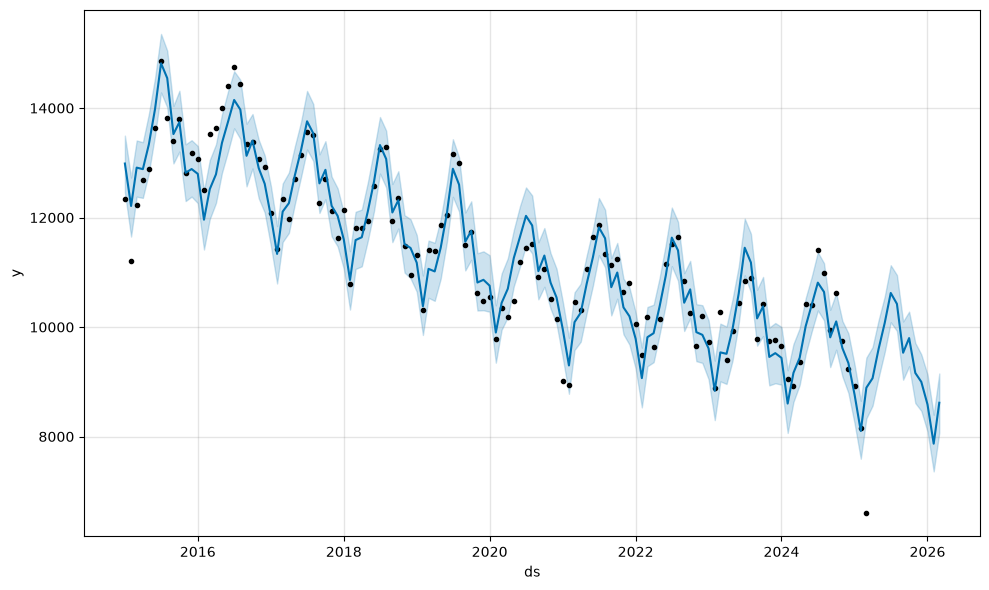

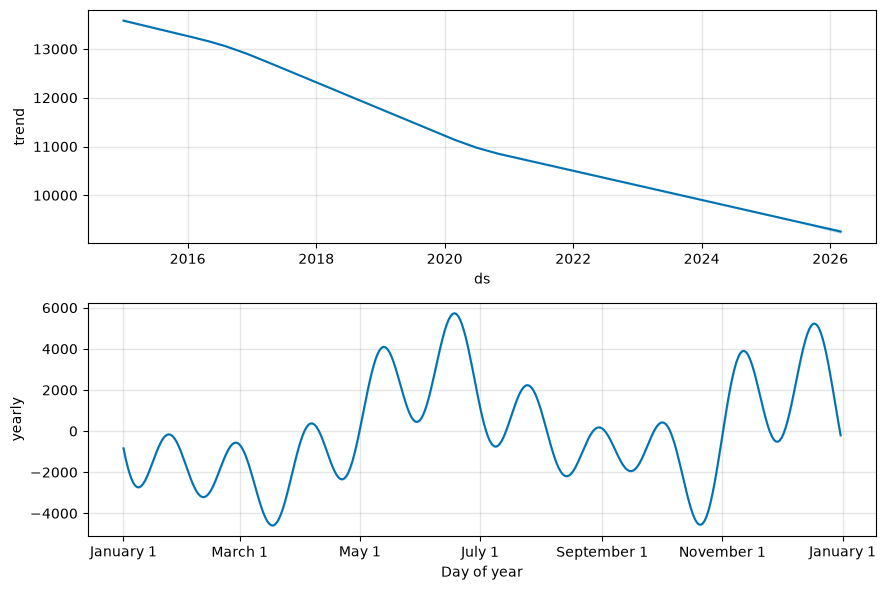

In [25]:
fig1 = model.plot(forecast)
fig2 = model.plot_components(forecast)

In [ ]:
merged = pd.merge(prophet_df[["ds", "y"]], forecast[["ds", "yhat"]], on="ds", how="inner")
mape = np.mean(np.abs((merged["y"] - merged["yhat"]) / merged["y"])) * 100

print(f"MAPE: {mape:.2f}%")

MAPE: 2.86%
